<h2>Data Gathetring</h2>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/Users/anshumdev/Desktop/Python/ML/churn-platform/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

<h2>Data Preproceccing</h2>

In [54]:
print(df.shape)

(7043, 21)


In [55]:
# we print random 5 value so we can see data properly because some time first five value not have some unique value
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4062,1915-IOFGU,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,70.50,70.5,Yes
1330,0661-WCQNQ,Male,0,Yes,No,22,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,Yes,Credit card (automatic),56.25,1292.2,No
3904,4803-LBYPN,Male,0,Yes,Yes,34,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.80,635.9,No
660,5650-VDUDS,Female,0,No,No,4,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,24.25,96.05,Yes
6126,9190-MFJLN,Male,1,No,No,19,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.90,1777.9,Yes


In [57]:
df.columns # see all the columns and understood what data given already 

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [58]:
print("DATA TYPES")
print(df.dtypes)

DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [60]:
print("MISSING VALUES")
print(df.isnull().sum()) # no null values 

MISSING VALUES
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [61]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [62]:
# Drop customerID (useless)
df = df.drop('customerID', axis=1)

In [63]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # basically its convert object to int and also if " " to NaN

In [64]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [65]:
#Fix missing values in TotalCharges
# We fill with median, not mean
# Why median? Because mean gets affected by outliers, median doesn't
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [66]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [67]:
binary_columns = ['gender', 'Partner', 'Dependents', 
                  'PhoneService', 'PaperlessBilling']   # these columns have only value 0 or 1
for i in binary_columns :
    df[i] = df[i].map(lambda x:1 if x in ['Yes','Female'] else 0)                  

In [68]:
print(df[binary_columns].head(3))

   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       1        1           0             0                 1
1       0        0           0             1                 0
2       0        0           0             1                 1


In [69]:
# now we have to do one hot encoding of those columns hove unique value more than 3
multi_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_columns)

In [70]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [71]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1329,1,0,1,0,72,1,0,19.40,1496.45,0,...,0,1,0,0,0,1,1,0,0,0
5977,0,0,0,0,57,1,0,20.65,1125.60,0,...,0,1,0,0,0,1,1,0,0,0
1722,1,0,0,0,51,0,1,56.40,2928.50,0,...,0,0,1,0,1,0,0,1,0,0
3174,0,0,1,0,58,0,1,45.00,2689.35,0,...,0,0,1,0,1,0,0,1,0,0
5095,1,0,0,0,55,1,0,45.05,2462.60,0,...,1,0,0,0,1,0,1,0,0,0


<h2>EDA - Exploratory Data Analysis</h2>

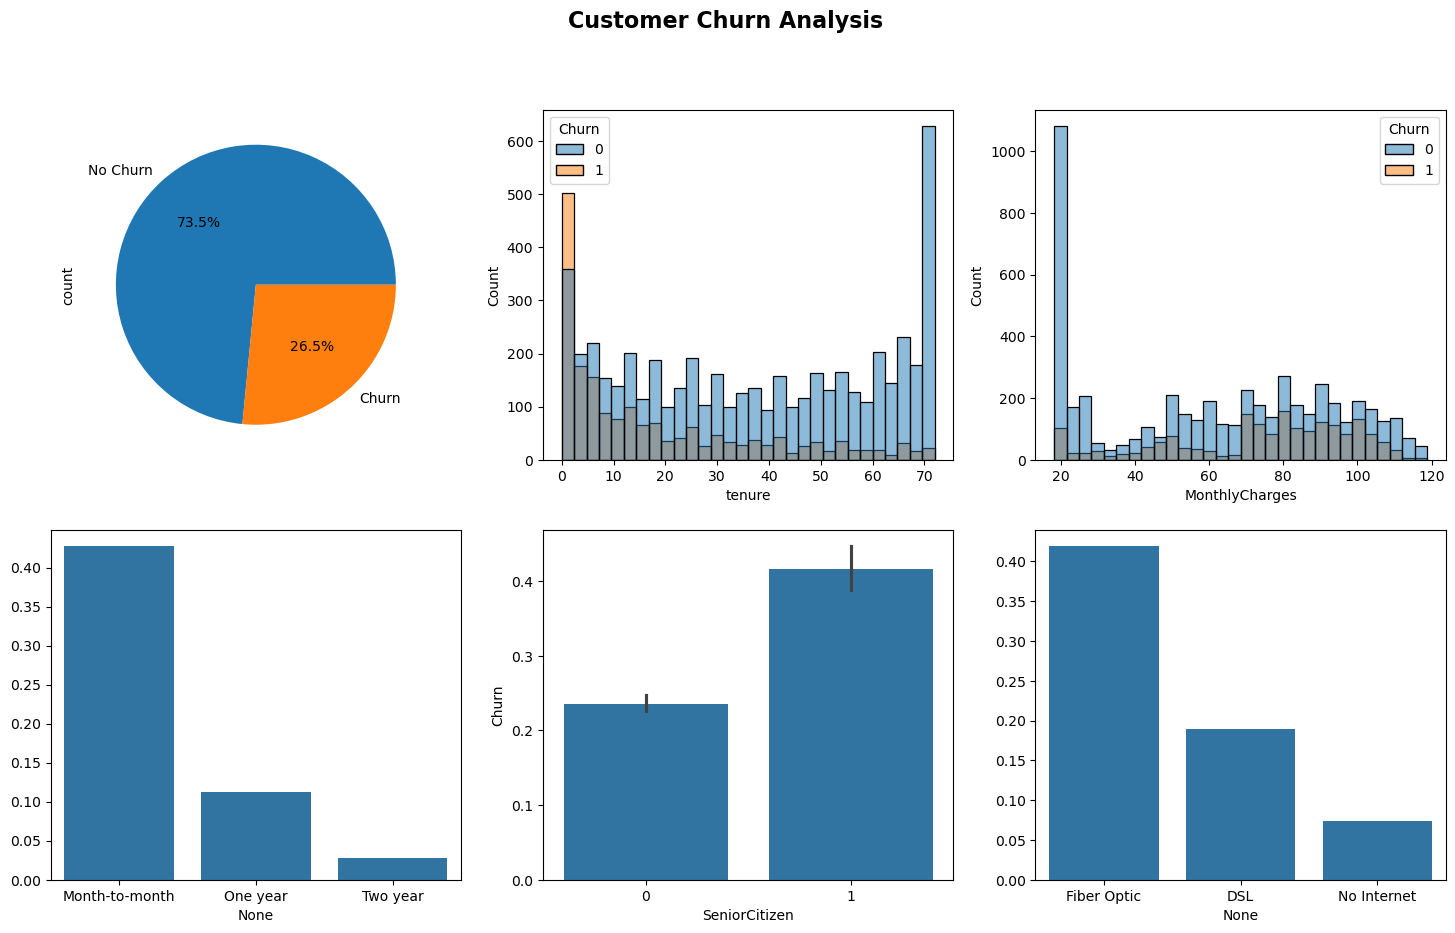

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn Analysis', fontsize=16, fontweight='bold')
#1.
df['Churn'].value_counts().plot(kind='pie', 
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    ax=axes[0,0])
#2.    
sns.histplot(data=df, x='tenure', hue= 'Churn',
    bins=30, ax=axes[0,1])  
#3.
sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
    bins=30, ax=axes[0,2])
#4.    
contract_churn = pd.Series({
    'Month-to-month': df[df['Contract_Month-to-month']==True]['Churn'].mean(),
    'One year':       df[df['Contract_One year']==True]['Churn'].mean(),
    'Two year':       df[df['Contract_Two year']==True]['Churn'].mean()
})
sns.barplot(x=contract_churn.index, y=contract_churn.values,
    ax=axes[1,0])    
#5.    
sns.barplot(data=df, x='SeniorCitizen', y='Churn',
    ax=axes[1,1])
#6.    
internet_churn = pd.Series({
    'Fiber Optic': df[df['InternetService_Fiber optic']==True]['Churn'].mean(),
    'DSL':         df[df['InternetService_DSL']==True]['Churn'].mean(),
    'No Internet': df[df['InternetService_No']==True]['Churn'].mean()
})
sns.barplot(x=internet_churn.index, y=internet_churn.values,
    ax=axes[1,2])
plt.savefig('../data/processed/eda_graphs.png', dpi=150, bbox_inches='tight')
plt.show()   

In [74]:
#"Before training any model, I analyzed the data and found that month-to-month customers churn at 43% vs 3% 
# for two-year contracts. This told me Contract and Tenure would be the most important features."
